## Step 1 - Uploading the dataset

For this task I selected a dataset related to energy usage and sustainability.

The dataset contains information about different buildings and their energy consumption patterns, water usage, waste generation and occupancy levels.

Since the data does not contain any output label, it is suitable for unsupervised learning techniques such as K-Means clustering.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Smart_Energy_Consumption_Dataset - Sheet1.csv to Smart_Energy_Consumption_Dataset - Sheet1.csv


## Step 2 - Importing the dataset

The uploaded dataset was imported using pandas so that it could be cleaned and analysed further.

Since the dataset does not contain any target column, it will be treated as an unsupervised learning problem.

In [2]:
import pandas as pd

df = pd.read_csv("Smart_Energy_Consumption_Dataset - Sheet1.csv")

In [4]:
df.head()

,Building,Building_Type,Energy_Consumption,Solar_Usage,Water_Consumption,Waste_Generated,Occupancy
0,B1,Residential,450,30,1200,45,120
1,B2,Commercial,920,20,2500,90,350
2,B3,Residential,500,35,1300,50,140
3,B4,Industrial,1800,10,4200,180,600
4,B5,Commercial,850,25,2300,85,320


In [5]:
df.shape

(15, 7)

## Step 3 - Getting familiar with the dataset

Before applying any machine learning algorithm, I first checked the structure of the dataset and the type of values present in each column.

This helps in understanding which columns are numerical, which are categorical and whether any preprocessing will be required.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Building            15 non-null     object
 1   Building_Type       15 non-null     object
 2   Energy_Consumption  15 non-null     int64 
 3   Solar_Usage         15 non-null     int64 
 4   Water_Consumption   15 non-null     int64 
 5   Waste_Generated     15 non-null     int64 
 6   Occupancy           15 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 972.0+ bytes


In [7]:
df.describe()

,Energy_Consumption,Solar_Usage,Water_Consumption,Waste_Generated,Occupancy
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,1062.666667,23.000000,2631.333333,105.266667,356.333333
std,578.464305,11.482907,1267.510872,57.364084,198.633426
min,450.000000,8.000000,1200.000000,45.000000,120.000000
25%,510.000000,13.500000,1325.000000,51.000000,142.500000
50%,890.000000,20.000000,2400.000000,88.000000,340.000000
75%,1765.000000,32.500000,4125.000000,172.500000,585.000000
max,1900.000000,42.000000,4400.000000,190.000000,620.000000


In [8]:
df.isnull().sum()

,0
Building,0
Building_Type,0
Energy_Consumption,0
Solar_Usage,0
Water_Consumption,0
Waste_Generated,0
Occupancy,0


## Step 4 - Observations from the dataset

After checking the dataset, I noticed that there were no missing values in any column, so no additional cleaning was required.

The dataset contains both categorical and numerical features.

Some initial observations:

- Industrial buildings seem to consume significantly more energy and water than residential buildings.
- Buildings with higher occupancy generally produce more waste.
- Solar usage appears to be higher in residential buildings compared to industrial buildings.
- Energy consumption and water consumption may have a positive relationship since larger buildings tend to consume more of both resources.

In [9]:
df["Resource_Efficiency"] = (
    df["Occupancy"] /
    (df["Energy_Consumption"] + df["Water_Consumption"])
)

In [10]:
df.head()

,Building,Building_Type,Energy_Consumption,Solar_Usage,Water_Consumption,Waste_Generated,Occupancy,Resource_Efficiency
0,B1,Residential,450,30,1200,45,120,0.072727
1,B2,Commercial,920,20,2500,90,350,0.102339
2,B3,Residential,500,35,1300,50,140,0.077778
3,B4,Industrial,1800,10,4200,180,600,0.100000
4,B5,Commercial,850,25,2300,85,320,0.101587


## Step 5 - Visualizing the data

Before clustering, I wanted to see if there were any visible patterns in the data.

Visualization makes it easier to understand how different features are related and whether similar groups already exist in the dataset.

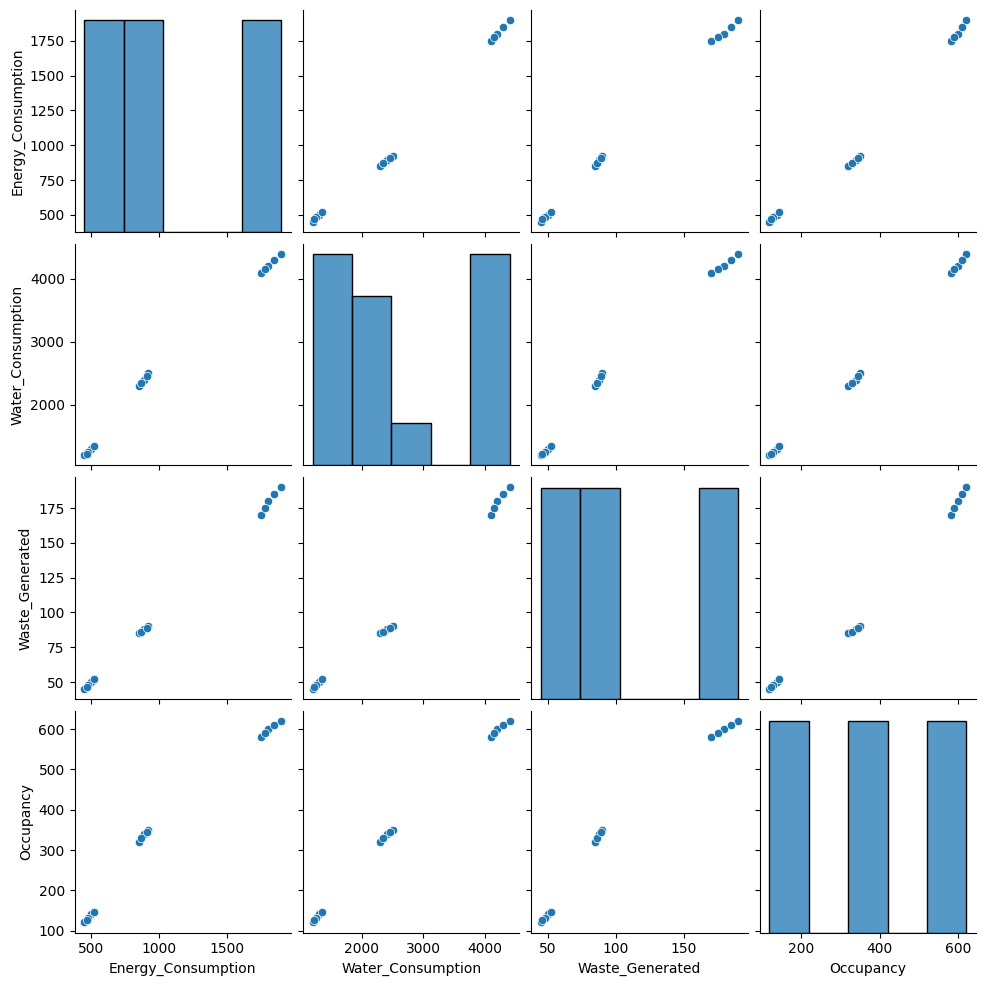

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[
        [
            "Energy_Consumption",
            "Water_Consumption",
            "Waste_Generated",
            "Occupancy"
        ]
    ]
)

plt.show()

## Step 6 - Preparing the data for clustering

K-Means clustering works only with numerical values and is sensitive to differences in scale.

Because of this, the categorical columns were converted into numerical form and the numerical columns were scaled so that one feature would not dominate the others during distance calculations.

In [12]:
df_encoded = pd.get_dummies(
    df,
    columns=["Building", "Building_Type"],
    drop_first=True
)

df_encoded.head()

,Energy_Consumption,Solar_Usage,Water_Consumption,Waste_Generated,Occupancy,Resource_Efficiency,Building_B10,Building_B11,Building_B12,Building_B13,...,Building_B2,Building_B3,Building_B4,Building_B5,Building_B6,Building_B7,Building_B8,Building_B9,Building_Type_Industrial,Building_Type_Residential
0,450,30,1200,45,120,0.072727,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,920,20,2500,90,350,0.102339,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,500,35,1300,50,140,0.077778,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,1800,10,4200,180,600,0.100000,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,850,25,2300,85,320,0.101587,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


## Step 7 - Scaling the numerical values

The numerical columns in the dataset have very different ranges. For example, water consumption values are much larger than solar usage values.

If the data is used directly, the larger values can dominate the clustering process.

To avoid this, StandardScaler was used to bring all numerical features to a similar scale.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

In [14]:
X_scaled[:5]

array([[-1.09629971,  0.63099777, -1.16888209, -1.0874736 , -1.23155627,
        -1.62149153, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.26726124, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.26726124, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.70710678,  1.41421356],
       [-0.25528633, -0.27042761, -0.10725187, -0.27547727, -0.03300362,
         0.82065835, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.26726124, -0.26726124,  3.74165739, -0.26726124, -0.26726124,
        -0.26726124, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.70710678, -0.70710678],
       [-1.0068302 ,  1.08171045, -1.08721823, -0.99725179, -1.1273343 ,
        -1.20496686, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.26726124, -0.26726124, -0.26726124,  3.74165739, -0.26726124,
        -0.26726124, -0.26726124, -0.26726124, -0.26726124, -0.26726124,
        -0.70710678,  1.41421356],
       [ 1.31937702

## Step 8 - Splitting the data

Although K-Means clustering does not strictly require train and test datasets, I created a train-test split to maintain consistency with the standard machine learning workflow used in previous experiments.

The clustering model will be trained on the training data and later analysed on the testing data.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

In [16]:
X_train.shape, X_test.shape

((12, 22), (3, 22))

## Step 9 - Applying K-Means clustering

After preparing the data, K-Means clustering was applied to group together buildings with similar consumption patterns.

Since the dataset mainly contains residential, commercial and industrial buildings, I expected around three major clusters to emerge naturally from the data.

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [18]:
clusters = kmeans.predict(X_scaled)

In [19]:
df["Cluster"] = clusters

In [20]:
df[["Building", "Building_Type", "Cluster"]]

,Building,Building_Type,Cluster
0,B1,Residential,1
1,B2,Commercial,0
2,B3,Residential,1
3,B4,Industrial,2
4,B5,Commercial,0
5,B6,Industrial,2
6,B7,Residential,1
7,B8,Commercial,0
8,B9,Industrial,2
9,B10,Residential,1


## Step 10 - Evaluating the clustering model

Since K-Means is an unsupervised learning algorithm, traditional metrics such as accuracy cannot be used.

Instead, the Silhouette Score was used to evaluate how well the clusters were separated from each other.

A value closer to 1 indicates better clustering, while values closer to 0 indicate overlapping clusters.

In [21]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.18171642002640515


## Step 11 - Observations and Final Thoughts

The K-Means model produced a Silhouette Score of 0.18.

This score suggests that the clusters are not very strongly separated and that some buildings share similar characteristics even if they belong to different building categories.

After looking at the dataset, this result makes sense because some commercial buildings have consumption patterns similar to larger residential buildings, while smaller industrial buildings can sometimes resemble commercial buildings.

Some observations from the analysis:

- Industrial buildings generally had the highest energy and water consumption.
- Residential buildings showed lower resource usage and generated less waste.
- Waste generation appeared to increase with occupancy.
- Buildings with larger occupancy values usually consumed more energy and water.
- Resource efficiency varied across different building types.

Although the clustering was not very strong, the model was still able to identify some common usage patterns among buildings.

If more features such as building age, operating hours or floor area were included, the clustering quality would likely improve.

In [22]:
print("WCSS:", kmeans.inertia_)

WCSS: 145.47544006516094


The WCSS value represents the compactness of the clusters. Lower values indicate that data points are closer to their cluster centers and the grouping is tighter.